Celda 1 — Setup (rutas e imports)


In [ ]:

import sys
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path("..").resolve()  
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("ROOT:", ROOT)
DATA_EXTERNAL = ROOT / "data" / "external"
DATA_RAW = ROOT / "data" / "raw"
print("external exists:", DATA_EXTERNAL.exists(), DATA_EXTERNAL)
print("raw exists:", DATA_RAW.exists(), DATA_RAW)


ROOT: C:\Users\javie\Documents\b\undac-thesis-smart-math-tutor
external exists: True C:\Users\javie\Documents\b\undac-thesis-smart-math-tutor\data\external
raw exists: True C:\Users\javie\Documents\b\undac-thesis-smart-math-tutor\data\raw


Celda 2 — Ver qué archivos KDD tienes 


In [2]:
kdd_files = sorted(DATA_EXTERNAL.glob("*.txt"))
[(p.name, p.stat().st_size // (1024*1024)) for p in kdd_files]  # (nombre, MB)


[('algebra_2005_2006.txt', 0),
 ('algebra_2005_2006_master.txt', 1),
 ('algebra_2005_2006_test.txt', 0),
 ('algebra_2005_2006_train.txt', 216)]

Celda 3 — Cargar un KDD crudo 

In [5]:
# Elige 1 archivo (master suele ser grande)
path = next(iter(sorted(DATA_EXTERNAL.glob("*train*.txt"))), None) or next(iter(sorted(DATA_EXTERNAL.glob("*.txt"))), None)
assert path is not None, "No encontré archivos .txt en data/external"

print("Leyendo:", path.name)

# nrows para explorar rápido
raw_kdd = pd.read_csv(path, sep="\t", low_memory=False, nrows=50_000)
raw_kdd.head(3)


Leyendo: algebra_2005_2006_train.txt


,Row,Anon Student Id,Problem Hierarchy,Problem Name,Problem View,Step Name,Step Start Time,First Transaction Time,Correct Transaction Time,Step End Time,Step Duration (sec),Correct Step Duration (sec),Error Step Duration (sec),Correct First Attempt,Incorrects,Hints,Corrects,KC(Default),Opportunity(Default)
0,1,0BrbPbwCMz,"Unit ES_04, Section ES_04-1",EG4-FIXED,1,3(x+2) = 15,2005-09-09 12:24:35.0,2005-09-09 12:24:49.0,2005-09-09 12:25:15.0,2005-09-09 12:25:15.0,40.0,NaN,40.0,0,2,3,1,[SkillRule: Eliminate Parens; {CLT nested; CLT...,1
1,2,0BrbPbwCMz,"Unit ES_04, Section ES_04-1",EG4-FIXED,1,x+2 = 5,2005-09-09 12:25:15.0,2005-09-09 12:25:31.0,2005-09-09 12:25:31.0,2005-09-09 12:25:31.0,16.0,16.0,NaN,1,0,0,1,"[SkillRule: Remove constant; {ax+b=c, positive...",1~~1
2,3,0BrbPbwCMz,"Unit ES_04, Section ES_04-1",EG40,1,2-8y = -4,2005-09-09 12:25:36.0,2005-09-09 12:25:43.0,2005-09-09 12:26:12.0,2005-09-09 12:26:12.0,36.0,NaN,36.0,0,2,3,1,"[SkillRule: Remove constant; {ax+b=c, positive...",2


Celda 4 — Entender columnas  (KDD)


In [28]:
raw_kdd.shape, raw_kdd.columns[:25].tolist()


((50000, 19),
 ['Row',
  'Anon Student Id',
  'Problem Hierarchy',
  'Problem Name',
  'Problem View',
  'Step Name',
  'Step Start Time',
  'First Transaction Time',
  'Correct Transaction Time',
  'Step End Time',
  'Step Duration (sec)',
  'Correct Step Duration (sec)',
  'Error Step Duration (sec)',
  'Correct First Attempt',
  'Incorrects',
  'Hints',
  'Corrects',
  'KC(Default)',
  'Opportunity(Default)'])

Celda 5 — Chequeos básicos del KDD (nulos, tipos, stats)


In [8]:
cols_interest = [
    "Anon Student Id",
    "Step Name",
    "Incorrects",
    "Hints",
    "Correct First Attempt",
    "Step Duration (sec)",
    "First Transaction Time",
]

present = [c for c in cols_interest if c in raw_kdd.columns]
missing = [c for c in cols_interest if c not in raw_kdd.columns]
print("Presentes:", present)
print("Faltantes:", missing)

raw_kdd[present].isna().mean().sort_values(ascending=False)


Presentes: ['Anon Student Id', 'Step Name', 'Incorrects', 'Hints', 'Correct First Attempt', 'Step Duration (sec)', 'First Transaction Time']
Faltantes: []


Step Duration (sec)       0.00068
Anon Student Id           0.00000
Step Name                 0.00000
Incorrects                0.00000
Hints                     0.00000
Correct First Attempt     0.00000
First Transaction Time    0.00000
dtype: float64

Celda 6 — Distribuciones crudas (errores, pistas, tiempo, CFA)


In [9]:
def describe_num(series):
    s = pd.to_numeric(series, errors="coerce")
    return pd.Series({
        "count": int(s.notna().sum()),
        "min": float(s.min()) if s.notna().any() else np.nan,
        "p50": float(s.quantile(0.5)) if s.notna().any() else np.nan,
        "p90": float(s.quantile(0.9)) if s.notna().any() else np.nan,
        "max": float(s.max()) if s.notna().any() else np.nan,
        "mean": float(s.mean()) if s.notna().any() else np.nan,
    })

for c in ["Incorrects", "Hints", "Step Duration (sec)", "Correct First Attempt"]:
    if c in raw_kdd.columns:
        print("\n==", c, "==")
        print(describe_num(raw_kdd[c]))



== Incorrects ==
count    50000.00000
min          0.00000
p50          0.00000
p90          1.00000
max        308.00000
mean         0.48266
dtype: float64

== Hints ==
count    50000.00000
min          0.00000
p50          0.00000
p90          0.00000
max         70.00000
mean         0.30912
dtype: float64

== Step Duration (sec) ==
count    49966.000000
min          0.000000
p50          9.000000
p90         59.000000
max       1791.000000
mean        26.077433
dtype: float64

== Correct First Attempt ==
count    50000.0000
min          0.0000
p50          1.0000
p90          1.0000
max          1.0000
mean         0.7719
dtype: float64


Ahora el dataset “del proyecto” (normalizado)


Celda 7 — Cargar dataset normalizado con DataLoader


In [13]:
from src.utils.config import ProjectConfig
from src.data_processing.data_loader import DataLoader

config = ProjectConfig()
loader = DataLoader(config)

base_df = loader.load_dataset()
base_df.head(3)


,student_id,step_name,incorrects,hints,correct_first_attempt,step_duration_sec,source_split,timestamp
0,0BrbPbwCMz,3(x+2) = 15,2.0,3.0,0,40.0,train,2005-09-09 12:24:49.0
1,0BrbPbwCMz,x+2 = 5,0.0,0.0,1,16.0,train,2005-09-09 12:25:31.0
2,0BrbPbwCMz,2-8y = -4,2.0,3.0,0,36.0,train,2005-09-09 12:25:43.0


Celda 8 — Ver columnas estándar y calidad (base)

In [14]:
base_df.shape, base_df.columns.tolist()


((813669, 8),
 ['student_id',
  'step_name',
  'incorrects',
  'hints',
  'correct_first_attempt',
  'step_duration_sec',
  'source_split',
  'timestamp'])

In [15]:
expected = ["student_id","step_name","incorrects","hints","correct_first_attempt","step_duration_sec"]
print("Faltantes:", [c for c in expected if c not in base_df.columns])

base_df[expected].isna().mean()


Faltantes: []


student_id               0.0
step_name                0.0
incorrects               0.0
hints                    0.0
correct_first_attempt    0.0
step_duration_sec        0.0
dtype: float64

In [16]:
base_df[expected].describe(include="all")


,student_id,step_name,incorrects,hints,correct_first_attempt,step_duration_sec
count,813669,813669,813669.000000,813669.000000,813669.000000,813669.000000
unique,576,188143,NaN,NaN,NaN,NaN
top,l5eh0S53tB,R1C1,NaN,NaN,NaN,NaN
freq,10129,26125,NaN,NaN,NaN,NaN
mean,NaN,NaN,0.501823,0.301007,0.762775,27.578208
std,NaN,NaN,2.032102,1.239761,0.425382,55.122152
min,NaN,NaN,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,0.000000,0.000000,1.000000,5.000000
50%,NaN,NaN,0.000000,0.000000,1.000000,11.000000
75%,NaN,NaN,0.000000,0.000000,1.000000,27.000000


Celda 9 — ¿De dónde vienen los datos? (source_split)


In [17]:
if "source_split" in base_df.columns:
    base_df["source_split"].value_counts(dropna=False)


Features + Target (cómo se “construye el modelo”)


Celda 10 — Construir features con FeatureEngineer


In [18]:
from src.data_processing.feature_engineering import FeatureEngineer

engineer = FeatureEngineer()
dataset = engineer.transform(base_df)

dataset.head(3)


,student_id,step_name,incorrects,hints,correct_first_attempt,step_duration_sec,source_split,timestamp,event_order,error_rate,...,student_avg_time_prev,student_accuracy_prev,step_success_rate_prev,step_len,step_num_ops,step_has_parentheses,step_num_digits,step_num_variables,step_abs_constant_sum,difficulty_level
0,0BrbPbwCMz,b+r*(x+y) = v-s,0.0,0.0,0,0.0,test,nan,809694,0.0,...,27.578208,0.762775,0.762775,15.0,5.0,1.0,0.0,6.0,0.0,2
1,0BrbPbwCMz,R7C1,0.0,0.0,0,0.0,test,nan,809695,0.0,...,0.000000,0.000000,0.762775,4.0,0.0,0.0,2.0,2.0,8.0,2
2,0BrbPbwCMz,m*(k-n) = g*s,0.0,0.0,0,0.0,test,nan,809696,0.0,...,0.000000,0.000000,0.762775,13.0,4.0,1.0,0.0,5.0,0.0,2


Celda 11 — Ver todas las features finales (inputs_modelo)


In [20]:
x, y = engineer.split_features_target(dataset)

print("X shape:", x.shape)
print("y shape:", y.shape)
print("features:", list(x.columns))

# Importante: el modelo NO usa difficulty_score como input
print("difficulty_score en X:", "difficulty_score" in x.columns)


X shape: (813669, 17)
y shape: (813669,)
features: ['incorrects', 'hints', 'step_duration_sec', 'correct_first_attempt', 'error_rate', 'time_efficiency', 'student_attempt_count_prev', 'student_avg_incorrects_prev', 'student_avg_time_prev', 'student_accuracy_prev', 'step_success_rate_prev', 'step_len', 'step_num_ops', 'step_has_parentheses', 'step_num_digits', 'step_num_variables', 'step_abs_constant_sum']
difficulty_score en X: False


Celda 12 — Explicar con números 2 features derivadas (fórmulas)


In [21]:
tmp = dataset[["incorrects","hints","step_duration_sec","correct_first_attempt","error_rate","time_efficiency"]].head(10).copy()
tmp["error_rate_check"] = tmp["incorrects"] / (tmp["incorrects"] + tmp["hints"] + 1)
tmp["time_eff_check"] = tmp["correct_first_attempt"] / (tmp["step_duration_sec"] + 1)
tmp


,incorrects,hints,step_duration_sec,correct_first_attempt,error_rate,time_efficiency,error_rate_check,time_eff_check
0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0


Celda 13 — Target final y su balance (difficulty_level)


In [22]:
dataset["difficulty_level"].value_counts().sort_index(), dataset["difficulty_level"].value_counts(normalize=True).sort_index()


(difficulty_level
 0    283191
 1    254526
 2    275952
 Name: count, dtype: int64,
 difficulty_level
 0    0.348042
 1    0.312813
 2    0.339145
 Name: proportion, dtype: float64)

Celda 14 — Ver cómo se calculan las “prev” (históricas) en un estudiante

In [23]:
# Elige un student_id con suficientes filas
sid = dataset["student_id"].value_counts().index[0]
student_rows = dataset[dataset["student_id"] == sid].sort_values("event_order").head(20)

student_rows[[
    "student_id","event_order",
    "incorrects","hints","correct_first_attempt","step_duration_sec",
    "student_attempt_count_prev",
    "student_avg_incorrects_prev","student_avg_time_prev","student_accuracy_prev",
]].reset_index(drop=True)


,student_id,event_order,incorrects,hints,correct_first_attempt,step_duration_sec,student_attempt_count_prev,student_avg_incorrects_prev,student_avg_time_prev,student_accuracy_prev
0,l5eh0S53tB,811155,0.0,0.0,0,0.0,0.0,0.501823,27.578208,0.762775
1,l5eh0S53tB,811156,0.0,0.0,0,0.0,1.0,0.000000,0.000000,0.000000
2,l5eh0S53tB,811157,0.0,0.0,0,0.0,2.0,0.000000,0.000000,0.000000
3,l5eh0S53tB,811158,0.0,0.0,0,0.0,3.0,0.000000,0.000000,0.000000
4,l5eh0S53tB,811159,0.0,0.0,0,0.0,4.0,0.000000,0.000000,0.000000
5,l5eh0S53tB,811160,0.0,0.0,0,0.0,5.0,0.000000,0.000000,0.000000
6,l5eh0S53tB,811161,0.0,0.0,0,0.0,6.0,0.000000,0.000000,0.000000
7,l5eh0S53tB,811162,0.0,0.0,0,0.0,7.0,0.000000,0.000000,0.000000
8,l5eh0S53tB,811163,0.0,0.0,0,0.0,8.0,0.000000,0.000000,0.000000
9,l5eh0S53tB,811164,0.0,0.0,0,0.0,9.0,0.000000,0.000000,0.000000


Entrenamiento (rápido, para entender)


Celda 15 — Entrenar en pequeño y ver leaderboard


In [24]:
from src.models.model_trainer import ModelTrainer

# muestra para que corra rápido
ds_small = dataset.head(20_000).copy()
x_small, y_small = engineer.split_features_target(ds_small)

trainer = ModelTrainer(config)
out = trainer.train(
    x_small,
    y_small,
    split_series=ds_small["source_split"] if "source_split" in ds_small.columns else None,
    time_series=ds_small["event_order"] if "event_order" in ds_small.columns else None,
    groups=ds_small["student_id"] if "student_id" in ds_small.columns else None,
)

print("validation_type:", out["validation_type"])
out["leaderboard"]


validation_type: group_student_holdout_split


,accuracy,precision,recall,f1_weighted,f1_macro,f1_score,auc_ovr_weighted,auc_ovr_macro,auc,model_name
0,0.999763,0.999763,0.999763,0.999763,0.999774,0.999763,1.000000,1.000000,1.000000,random_forest
2,0.999763,0.999763,0.999763,0.999763,0.999774,0.999763,0.999669,0.999747,0.999669,gradient_boosting
1,0.997865,0.997877,0.997865,0.997867,0.997860,0.997867,0.999990,0.999987,0.999990,logistic_regression


Logs del juego y métricas de “aprendizaje” (panel admin)


In [25]:
from src.app.learning_metrics import compute_learning_metrics_from_logs

metrics = compute_learning_metrics_from_logs(config.gameplay_log_path)
metrics["overall"], pd.DataFrame(metrics.get("per_user", []))


({'attempts': 8,
  'unique_users': 1,
  'unique_students': 1,
  'accuracy': 0.625,
  'avg_time_sec': 15.3695195,
  'avg_hints': 0.125,
  'avg_incorrects': 1.125,
  'help_dependency': 0.2,
  'avg_attempts_to_resolve': 1.6,
  'oscillation_rate': 0.0},
   username  attempts  accuracy  avg_time_sec  avg_hints  avg_incorrects  \
 0   user01         8     0.625     15.369519      0.125           1.125   
 
    help_dependency  avg_attempts_to_resolve  oscillation_rate  \
 0              0.2                      1.6               0.0   
 
    delta_accuracy_2half  delta_time_2half  delta_hints_2half  \
 0                  0.75           5.00331               0.25   
 
    delta_incorrects_2half  
 0                   -0.75  )

In [19]:
Celda 8 — Ver columnas estándar y calidad (base)


SyntaxError: invalid character '—' (U+2014) (811039008.py, line 1)

In [ ]:
import numpy as np
import pandas as pd

def profile_dataframe(df: pd.DataFrame, top_k: int = 5) -> dict[str, pd.DataFrame]:
    out_num = []
    out_cat = []

    for col in df.columns:
        s = df[col]
        na_rate = float(s.isna().mean())

        # intenta numérico
        s_num = pd.to_numeric(s, errors="coerce")
        num_rate = float(s_num.notna().mean())

        if num_rate > 0.85:  # si "casi todo" se puede convertir a número
            v = s_num.dropna()
            out_num.append({
                "col": col,
                "count": int(v.size),
                "na_rate": na_rate,
                "min": float(v.min()) if v.size else np.nan,
                "p50": float(v.quantile(0.50)) if v.size else np.nan,
                "p90": float(v.quantile(0.90)) if v.size else np.nan,
                "p99": float(v.quantile(0.99)) if v.size else np.nan,
                "max": float(v.max()) if v.size else np.nan,
                "mean": float(v.mean()) if v.size else np.nan,
            })
        else:
            v = s.astype(str).fillna("")
            v2 = v.replace("nan", "").replace("None", "")
            vc = v2.value_counts(dropna=False).head(top_k)
            out_cat.append({
                "col": col,
                "na_rate": na_rate,
                "n_unique": int(v2.nunique(dropna=False)),
                "top_values": "; ".join([f"{idx}:{cnt}" for idx, cnt in vc.items()]),
            })

    return {
        "numeric": pd.DataFrame(out_num).sort_values(["na_rate", "col"]),
        "categorical": pd.DataFrame(out_cat).sort_values(["na_rate", "col"]),
    }

# Ejemplo: raw_kdd es tu dataframe crudo KDD
profile = profile_dataframe(raw_kdd, top_k=5)
profile["numeric"].head(20)


,col,count,na_rate,min,p50,p90,p99,max,mean
3,Correct First Attempt,50000,0.00000,0.0,1.0,1.0,1.00,1.0,0.771900
6,Corrects,50000,0.00000,0.0,1.0,2.0,4.00,21.0,1.154340
5,Hints,50000,0.00000,0.0,0.0,0.0,5.00,70.0,0.309120
4,Incorrects,50000,0.00000,0.0,0.0,1.0,7.00,308.0,0.482660
1,Problem View,50000,0.00000,1.0,1.0,2.0,7.00,17.0,1.495240
0,Row,50000,0.00000,1.0,34335.5,62098.1,68083.01,68693.0,34257.678340
2,Step Duration (sec),49966,0.00068,0.0,9.0,59.0,286.00,1791.0,26.077433


In [ ]:
import numpy as np
import pandas as pd

def numeric_cols(df: pd.DataFrame, min_numeric_rate: float = 0.85) -> list[str]:
    cols = []
    for c in df.columns:
        s = pd.to_numeric(df[c], errors="coerce")
        if float(s.notna().mean()) >= min_numeric_rate:
            cols.append(c)
    return cols

def outliers_iqr(df: pd.DataFrame, cols: list[str] | None = None) -> pd.DataFrame:
    cols = cols or numeric_cols(df)
    rows = []
    for c in cols:
        s = pd.to_numeric(df[c], errors="coerce").dropna()
        if s.empty:
            continue
        q1 = float(s.quantile(0.25))
        q3 = float(s.quantile(0.75))
        iqr = q3 - q1
        if iqr == 0:
            lower = q1
            upper = q3
        else:
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr

        out = s[(s < lower) | (s > upper)]
        rows.append({
            "col": c,
            "count": int(s.size),
            "na_rate": float(pd.to_numeric(df[c], errors="coerce").isna().mean()),
            "q1": q1,
            "q3": q3,
            "iqr": float(iqr),
            "lower": float(lower),
            "upper": float(upper),
            "outliers_n": int(out.size),
            "outliers_rate": float(out.size / s.size),
            "min": float(s.min()),
            "p99": float(s.quantile(0.99)),
            "max": float(s.max()),
        })
    return pd.DataFrame(rows).sort_values(["outliers_rate", "outliers_n"], ascending=False)

def outliers_zscore(df: pd.DataFrame, cols: list[str] | None = None, z: float = 4.0) -> pd.DataFrame:
    cols = cols or numeric_cols(df)
    rows = []
    for c in cols:
        s = pd.to_numeric(df[c], errors="coerce").dropna().astype(float)
        if s.size < 10:
            continue
        mu = float(s.mean())
        sigma = float(s.std(ddof=0))
        if sigma == 0:
            continue
        zvals = (s - mu) / sigma
        out = s[zvals.abs() >= z]
        rows.append({
            "col": c,
            "count": int(s.size),
            "mean": mu,
            "std": sigma,
            "z_thresh": z,
            "outliers_n": int(out.size),
            "outliers_rate": float(out.size / s.size),
            "min": float(s.min()),
            "p99": float(s.quantile(0.99)),
            "max": float(s.max()),
        })
    return pd.DataFrame(rows).sort_values(["outliers_rate", "outliers_n"], ascending=False)

# Usa raw_kdd (KDD crudo) o base_df/dataset (del proyecto)
iqr_report = outliers_iqr(raw_kdd)
iqr_report.head(20)


,col,count,na_rate,q1,q3,iqr,lower,upper,outliers_n,outliers_rate,min,p99,max
3,Correct First Attempt,50000,0.00000,1.00,1.00,0.0,1.0,1.0,11405,0.228100,0.0,1.00,1.0
4,Incorrects,50000,0.00000,0.00,0.00,0.0,0.0,0.0,10211,0.204220,0.0,7.00,308.0
6,Corrects,50000,0.00000,1.00,1.00,0.0,1.0,1.0,7687,0.153740,0.0,4.00,21.0
2,Step Duration (sec),49966,0.00068,4.00,23.00,19.0,-24.5,51.5,5762,0.115318,0.0,286.00,1791.0
5,Hints,50000,0.00000,0.00,0.00,0.0,0.0,0.0,4979,0.099580,0.0,5.00,70.0
1,Problem View,50000,0.00000,1.00,2.00,1.0,-0.5,3.5,2566,0.051320,1.0,7.00,17.0
0,Row,50000,0.00000,17042.75,51443.25,34400.5,-34558.0,103044.0,0,0.000000,1.0,68083.01,68693.0


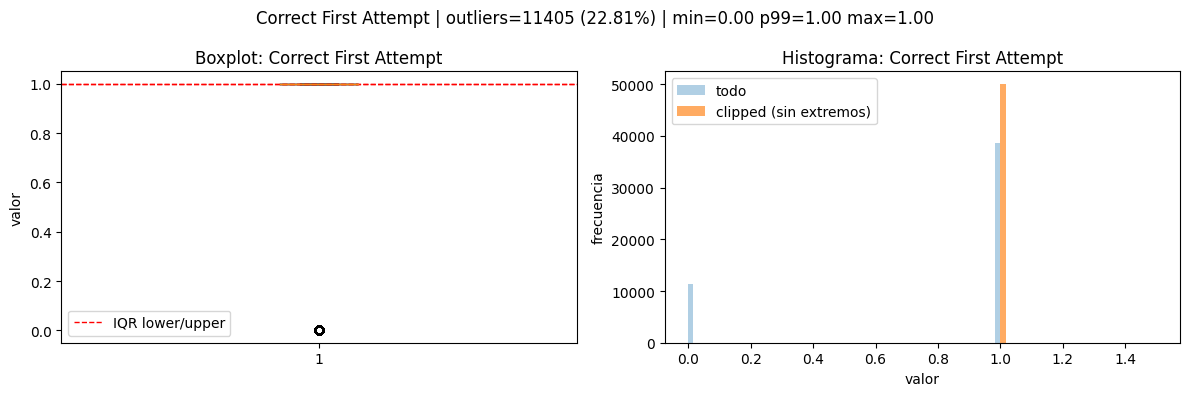

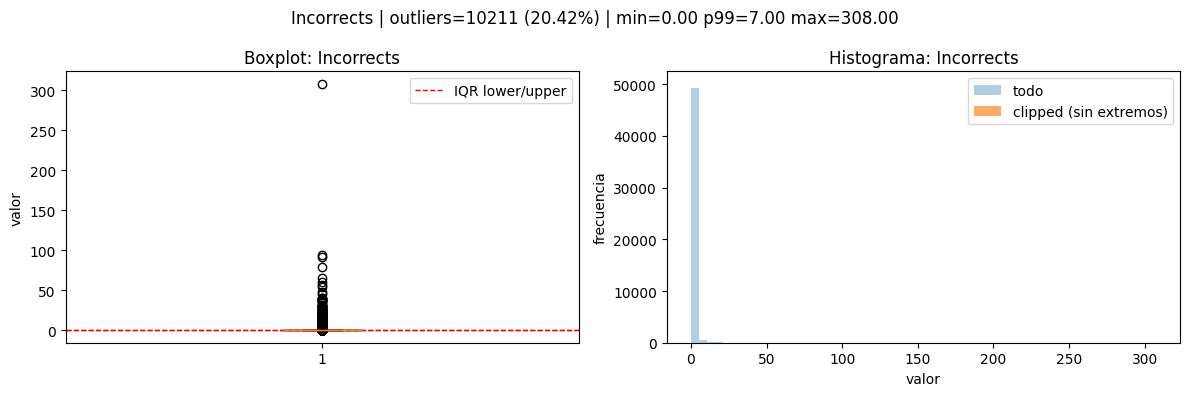

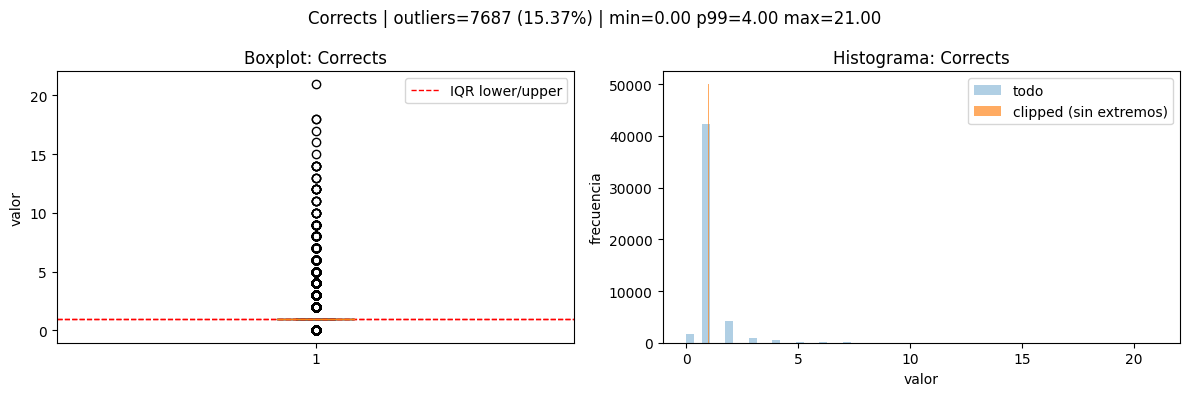

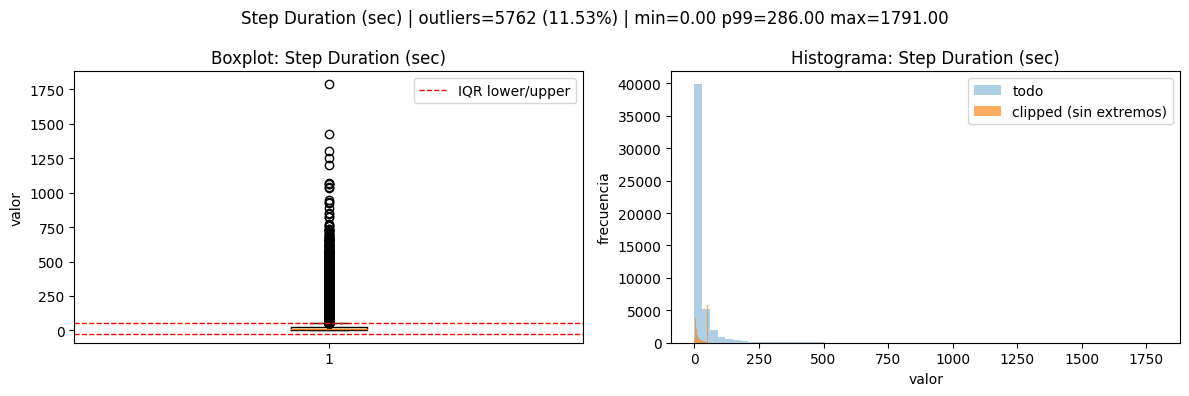

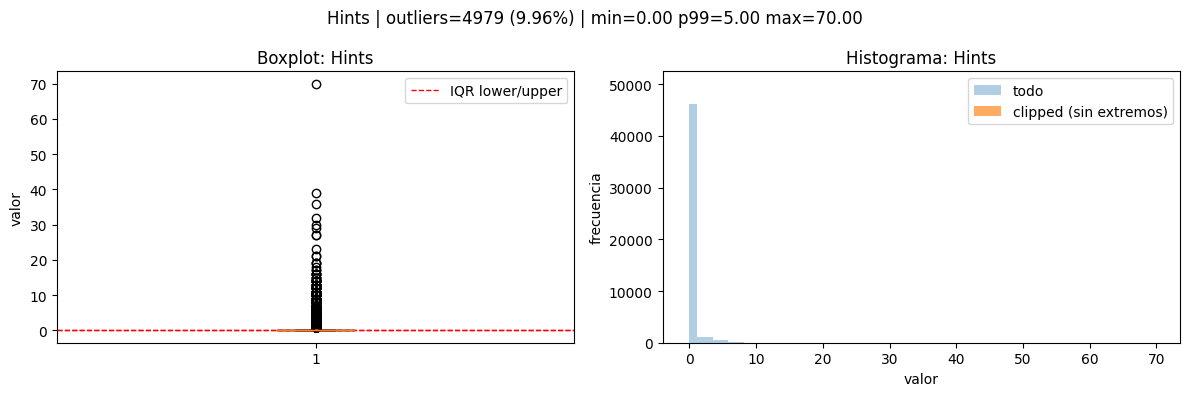

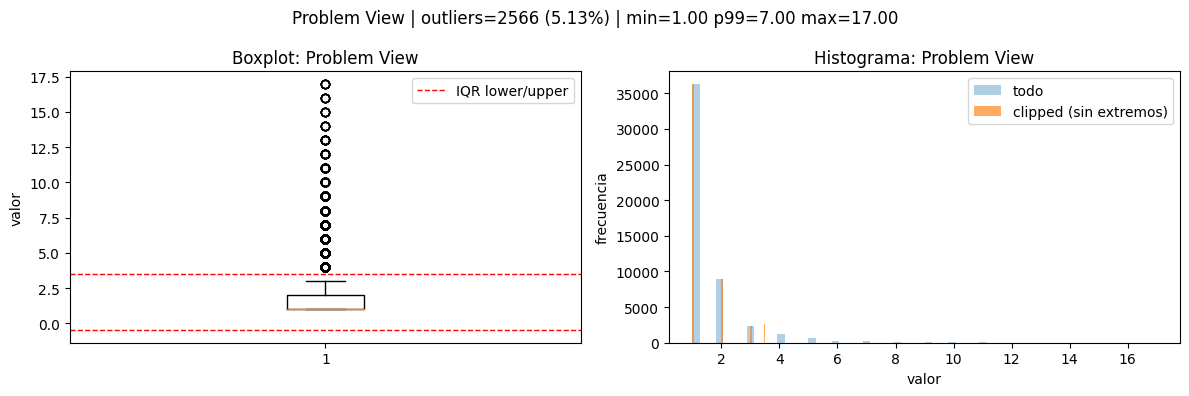

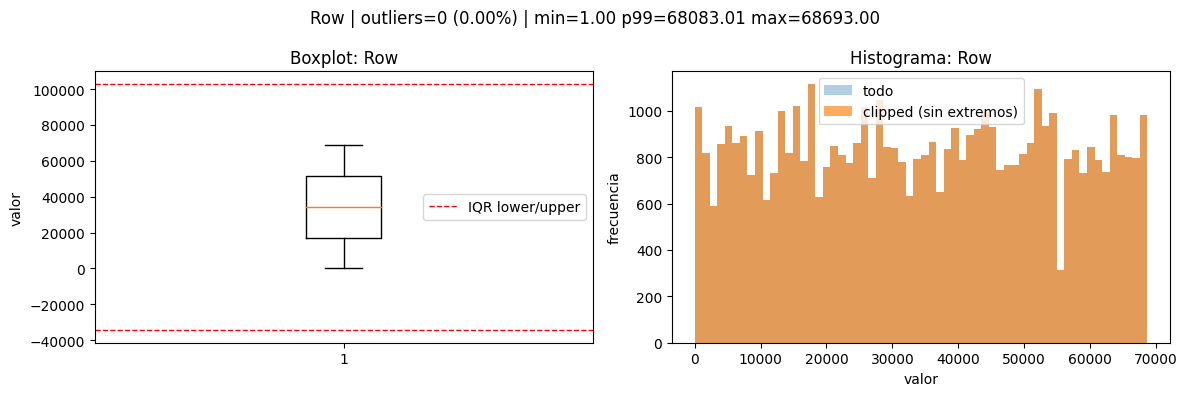

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_top_outliers_iqr(df, iqr_report, top_n=10, bins=60):
    top = iqr_report.head(top_n).copy()
    cols = top["col"].tolist()

    for c in cols:
        s = pd.to_numeric(df[c], errors="coerce").dropna()
        if s.empty:
            continue

        row = top[top["col"] == c].iloc[0]
        lower, upper = float(row["lower"]), float(row["upper"])

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        # Boxplot (muestra outliers)
        axes[0].boxplot(s.values, vert=True, showfliers=True)
        axes[0].set_title(f"Boxplot: {c}")
        axes[0].set_ylabel("valor")
        axes[0].axhline(lower, color="red", linestyle="--", linewidth=1, label="IQR lower/upper")
        axes[0].axhline(upper, color="red", linestyle="--", linewidth=1)
        axes[0].legend(loc="best")

        # Histograma: todo + zoom sin outliers
        clipped = s.clip(lower=lower, upper=upper)
        axes[1].hist(s.values, bins=bins, alpha=0.35, label="todo")
        axes[1].hist(clipped.values, bins=bins, alpha=0.65, label="clipped (sin extremos)")
        axes[1].set_title(f"Histograma: {c}")
        axes[1].set_xlabel("valor")
        axes[1].set_ylabel("frecuencia")
        axes[1].legend(loc="best")

        fig.suptitle(
            f"{c} | outliers={int(row['outliers_n'])} ({row['outliers_rate']:.2%}) | "
            f"min={row['min']:.2f} p99={row['p99']:.2f} max={row['max']:.2f}"
        )
        plt.tight_layout()
        plt.show()

# Ejecución
iqr_report = outliers_iqr(raw_kdd)
plot_top_outliers_iqr(raw_kdd, iqr_report, top_n=10, bins=60)
